# Optimization for Machine Learning: Computer Lab 1

## 2. Preprocessing the data

Here, we load the data, standardize it, and set it in the appropriate shape for performing linear regression. You do not need to complete anything in this section; however it is important that you understand what the code is doing. See the pdf instructions for more details.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Loading data
data_matrix_train, COP_train, data_matrix_test, COP_test, names = np.load('data_center_data_matrix.npy', allow_pickle=True)

In [3]:
# centering and normalizing the matrix
matrix_mean = np.mean(data_matrix_train, axis=0)
M = data_matrix_train - matrix_mean

matrix_std = np.std(M, axis=0)
M = M / matrix_std

In [4]:
M.shape

(722, 892)

In [5]:
# Building the corresponding matrices A,b for linear regression
A = np.hstack([M, np.ones((M.shape[0],1)), -(M.T * COP_train[:,3]).T])
b = COP_train[:,3]

# Building the same matrices for the test set
M_test = (data_matrix_test - matrix_mean) / matrix_std
A_test = np.hstack([M_test, np.ones((M_test.shape[0],1)), -(M_test.T * COP_test[:,3]).T])
b_test = COP_test[:,3]

d = A.shape[1]

## 3. Ordinary least squares

We now wish to solve the problem
$$
\min_{w \in \mathbb{R}^d} \frac 12 \|Aw-b\|_2^2
$$

In [6]:
## Question 3.2: solve with the numpy least squares solver

# COMPLETE HERE
w_least_squares = np.linalg.lstsq(A, b)[0]

In [7]:
## Question 3.3

# COMPLETE HERE
test_error = np.linalg.norm(A_test@w_least_squares-b_test)**2/len(M_test)
print("Test error for least squares solution : ", test_error)

Test error for least squares solution :  780.8984793522795


### Adding $\ell_2$ regularization

In order to improve the performance on the test set, we add $\ell_2$ regularization:

$$
\min_{w \in \mathbb{R}^d} \frac 12 \|Aw-b\|_2^2 + \frac \lambda 2 \|w\|_2^2
$$

In [8]:
lambda_l2 = 0

In [9]:
# Question 3.5
def f(w):
    # COMPLETE HERE
    return 1/2*np.linalg.norm(A@w+b)**2+(lambda_l2/2) * np.linalg.norm(w)**2

def grad_f(w):
    # COMPLETE HERE
    return A.T @ (A@w-b)+lambda_l2*w
def gradient_descent(f, grad_f, w0, gamma, max_iter):
    w = w0.copy()
    
    f_values = []
    gradient_norms = []

    iter_needed=False
    for t in range(max_iter):
        # COMPLETE HERE 
        w = w- gamma * grad_f(w)
        if np.linalg.norm(grad_f(w))<=1 and not iter_needed:
            print(f"Num of iterations needed : {t}")
            iter_needed=True
        f_values.append(f(w))
        gradient_norms.append(np.linalg.norm(grad_f(w)))
        
    return w, f_values, gradient_norms

For finding the appropriate step size range, we need to estimate the Lipschitz constant of the gradient.

$\nabla f(w)=A^T(Aw-b) + \lambda w$

$\nabla f(x)-\nabla f(y) = A^TA(x-y) + \lambda (x-y)=(A^TA+I)(x-y)$

So $$||\nabla f(x)- \nabla f(y)||\leq ||A^TA+I||_\infty ||x-y||$$

In [10]:
# COMPLETE HERE
Mat = A.T @ A + lambda_l2* np.eye(A.shape[1])

L = np.linalg.norm(Mat, ord=np.inf)

In [11]:
# COMPLETE HERE
w0 = np.random.random(len(Mat))
step_size = 1/L
max_iter = 100000

w_GD, f_values_GD, gradient_norms_GD = gradient_descent(f, grad_f, w0, step_size, max_iter)

We now compute the evolution of function values and gradient norm. 

Text(0, 0.5, 'Function values')

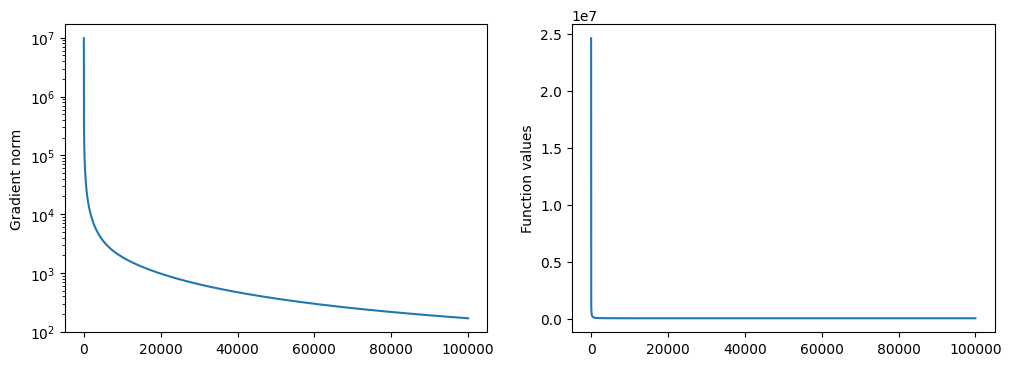

In [12]:
# let us plot the result 
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

axes[0].plot(gradient_norms_GD)
axes[0].semilogy()
axes[0].set_ylabel("Gradient norm")

axes[1].plot(f_values_GD)
axes[1].set_ylabel("Function values")

In [13]:
# Question 3.6 

test_error_l2 = np.linalg.norm(A_test@w_GD-b_test)**2/len(M_test)# COMPLETE HERE
print("Test error for l2 penalized solution : ", test_error_l2)

Test error for l2 penalized solution :  394818.32810260233


What do you observe ?

We have found a better solution for our test sample.

### Line search

The step size given by theory is can be too conservative in practice. We propose to implement a backtracking line search procedure to find a better one automatically.


In [14]:
# Question 3.7

def gradient_descent_line_search(f, grad_f, w0, gamma_0, max_iter):
    w = w0.copy()

    # initial step size
    gamma = gamma_0.copy() 
    
    f_values = []
    gradient_norms = []

    for t in range(max_iter):
        # COMPLETE HERE
        # while ...
        gamma_p = gamma
        w_new = w-gamma_p*grad_f(w)
        while True:
            if f(w_new)<= f(w)+ grad_f(w).T@(w_new-w)+1/(2*gamma_p)*np.linalg.norm(w_new+w)**2:
                w= w_new 
                gamma = 2 * gamma_p
                break
            gamma_p = gamma_p/2
        f_values.append(f(w))
        gradient_norms.append(np.linalg.norm(grad_f(w)))
        
    return w, f_values, gradient_norms

In [15]:
# COMPLETE HERE
w0 = np.random.random(len(Mat))
step_size = 1/L
max_iter = 10000

w_GD_LS, f_values_GD_LS, gradient_norms_GD_LS = gradient_descent_line_search(f, grad_f, w0, step_size, max_iter)

Text(0, 0.5, 'Function values with line search')

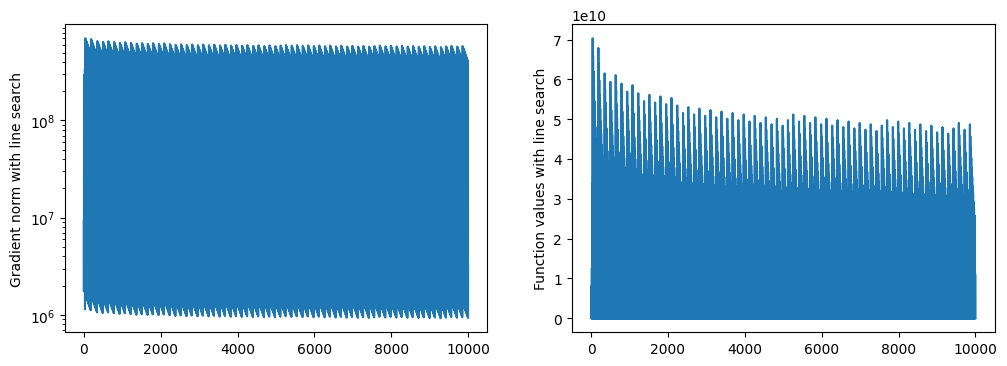

In [16]:
# let us plot the result 
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

axes[0].plot(gradient_norms_GD_LS)
axes[0].semilogy()
axes[0].set_ylabel("Gradient norm with line search")

axes[1].plot(f_values_GD_LS)
axes[1].set_ylabel("Function values with line search")

### Accelerated gradient method
For a faster algorithm, we could implement accelerated gradient descent.

In [17]:
# Question 3.8 (optional) 

def accelerated_gradient_descent(f, grad_f, w0, gamma, max_iter):
    # COMPLETE HERE
    w = w0.copy()
    y = w0.copy()
    f_values = []
    gradient_norms = []

    for t in range(max_iter):
        y_new = w - gamma * grad_f(w)
        w_new = y_new + (y_new-y)*(t+1)/(t+4)
        y = y_new
        w= w_new
        f_values.append(f(y))
        gradient_norms.append(np.linalg.norm(grad_f(y)))
        
    return w, f_values, gradient_norms

In [18]:
# COMPLETE HERE
w0 = np.random.random(len(Mat))
step_size = 1/L
max_iter = 100000

w_AGD, f_values_AGD, gradient_norms_AGD = accelerated_gradient_descent(f, grad_f, w0, step_size, max_iter)

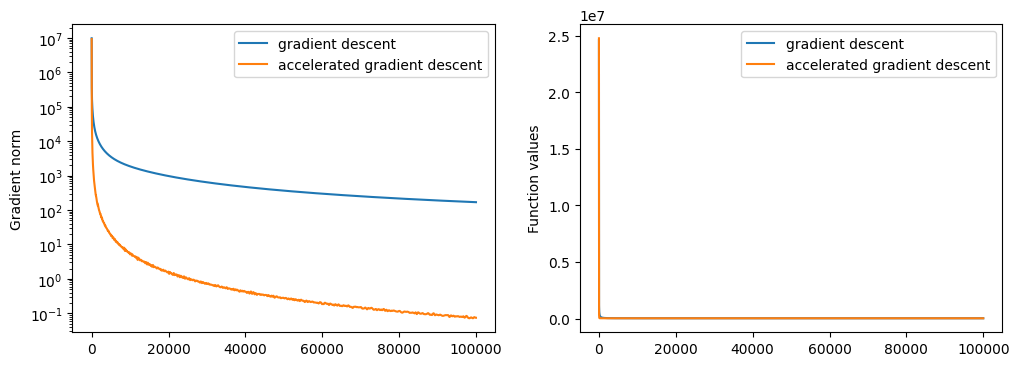

In [19]:
# let us plot the result 
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

axes[0].plot(gradient_norms_GD, label = "gradient descent")
axes[0].plot(gradient_norms_AGD, label = "accelerated gradient descent")
axes[0].semilogy()
axes[0].set_ylabel("Gradient norm")
axes[0].legend()

axes[1].plot(f_values_GD, label = "gradient descent")
axes[1].plot(f_values_AGD, label = "accelerated gradient descent")
axes[1].set_ylabel("Function values")
axes[1].legend()

What do you observe regarding the convergence speed ?

The convergence speed is way faster in the accelerated version.

## 4. Adding $\ell_1$ regularization (Lasso)

We now solve 

$$
\min_{w \in \mathbb{R}^d} \frac 12 \|Aw-b\|_2^2 + \lambda \|w\|_1
$$

In [20]:
lambda_l1 = 1e3

## Question 4.2
def prox_l1(x, mu = 1.):
    """compute the proximal operator of mu * |x|_1
    """
    # COMPLETE HERE
    # ....
    s = np.zeros_like(x)
    for i in range(len(x)):
        if x[i]<-mu:
            s[i]=x[i]+mu
        elif -mu<=x[i]<=mu:
            s[i]=0
        else:
            s[i]=x[i]-mu
    return s

def proximal_gradient_descent(f, grad_f, w0, gamma, max_iter):
    w = w0.copy()

    f_values = []
    gradient_norms = []

    for t in range(max_iter):
        # COMPLETE HERE
        # w = ....
        w = prox_l1(w-(1/L)*grad_f(w))

        f_values.append(f(w))
        gradient_norms.append(np.linalg.norm(grad_f(w)))
        
    return w, f_values, gradient_norms

In [21]:
# COMPLETE HERE
w0 = np.random.random(len(Mat))
step_size = 1/L
max_iter = 100000

w_PGD, f_values_PGD, gradient_norms_PGD = proximal_gradient_descent(f, grad_f, w0, step_size, max_iter)

In [22]:
# Question 4.3

test_error_l1 = np.linalg.norm(A_test@w_PGD-b_test)**2/len(M_test)# COMPLETE HERE
print("Test error for l1 penalized solution : ", test_error_l1)

Test error for l1 penalized solution :  79.82867294741004


Compare with the previous test errors. What do you observe?

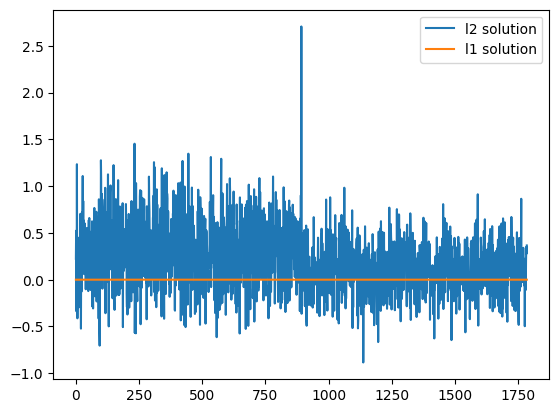

In [23]:
# Let us examine the solution
plt.plot(w_GD, label = "l2 solution")
plt.plot(w_PGD, label = "l1 solution")
plt.legend()

What do you observe regarding the difference in **structure** of the two solutions?

The $\ell_1$ solution is more stable and gives good results compared to the $\ell_2$ solution. 

## [BONUS] Tuning the penalization parameter

How to find the best solution among all those that were comptued? How to choose the penalization parameter $\lambda$?

In [24]:
# Your method here...